/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


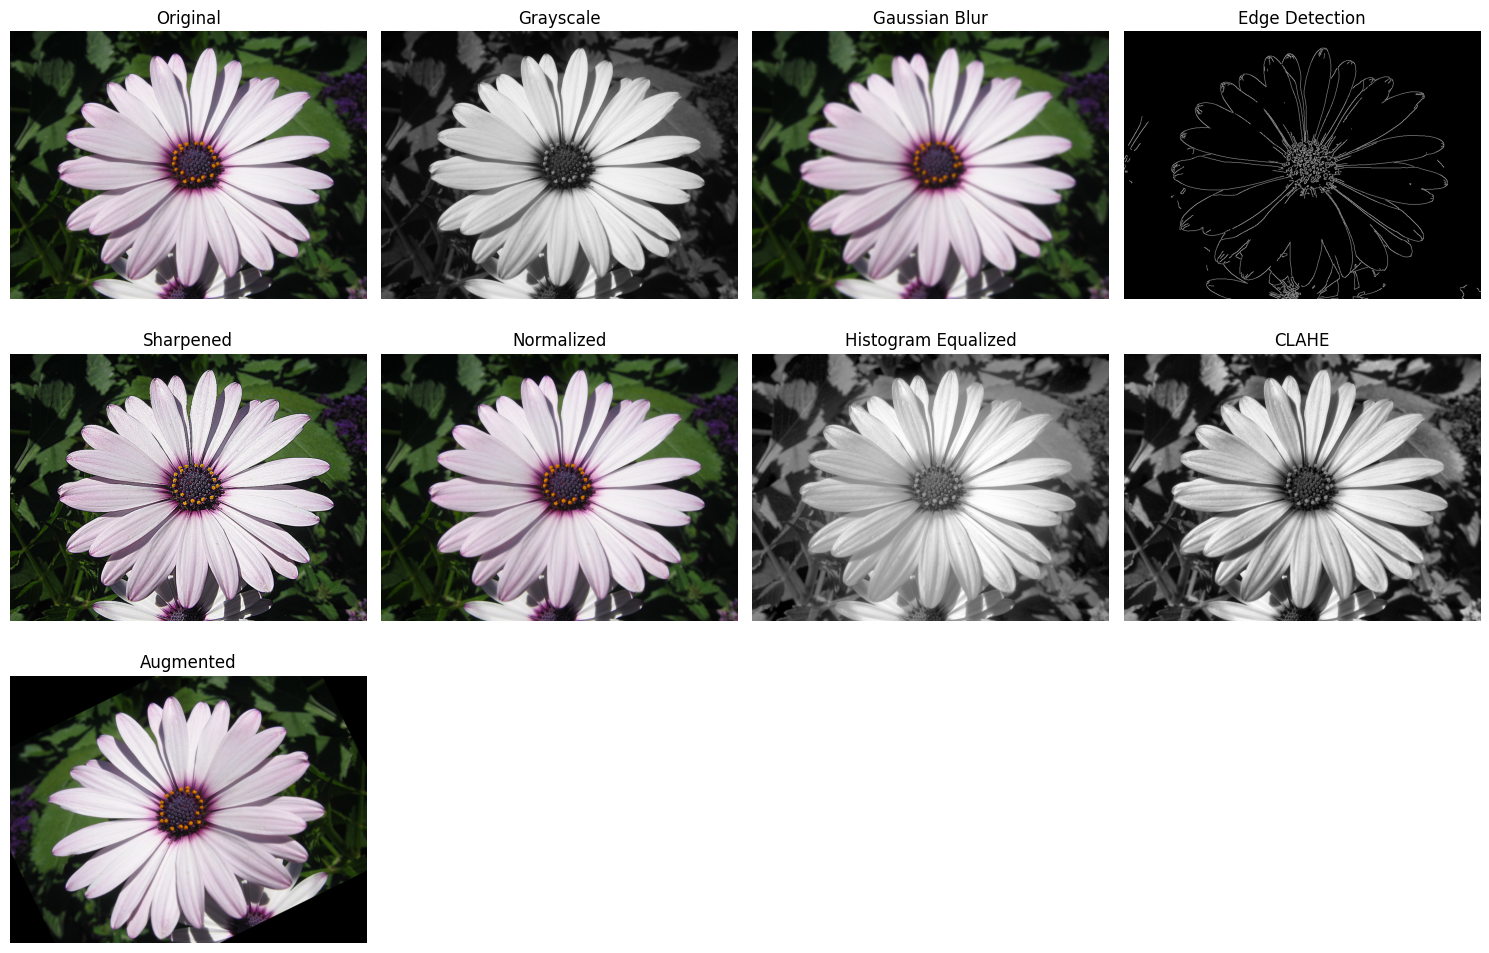

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from PIL import Image

def display_images(images, titles, cols=4):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(15, 10))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def apply_preprocessing(image_path):
    img = cv2.imread(image_path)

    # Techniques
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(img, (15, 15), 0)
    edges = cv2.Canny(img, 100, 200)
    sharpen_kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    sharpen = cv2.filter2D(img, -1, sharpen_kernel)

    # Normalization
    normalized = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

    # Histogram Equalization
    gray_eq = cv2.equalizeHist(gray)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_applied = clahe.apply(gray)

    # Augmentation using Albumentations
    augmenter = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.Rotate(limit=30, p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=20, p=0.5)
    ])
    augmented = augmenter(image=img)['image']

    # Convert single-channel images to 3-channel for display consistency
    gray_colored = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    edges_colored = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
    gray_eq_colored = cv2.cvtColor(gray_eq, cv2.COLOR_GRAY2BGR)
    clahe_colored = cv2.cvtColor(clahe_applied, cv2.COLOR_GRAY2BGR)

    # Display results
    images = [img, gray_colored, blur, edges_colored, sharpen, normalized, gray_eq_colored, clahe_colored, augmented]
    titles = ["Original", "Grayscale", "Gaussian Blur", "Edge Detection", "Sharpened", "Normalized", "Histogram Equalized", "CLAHE", "Augmented"]

    display_images(images, titles)

# Example usage
apply_preprocessing('/content/flower.jpg')


In [2]:
'''
what these preprocessing techniques do?
Grayscale Conversion: Converts the image to grayscale, reducing the complexity of the image data and focusing on intensity variations.
Gaussian Blur: Applies a Gaussian blur to smooth out noise and reduce high-frequency components in the image.
Edge Detection (Canny): Detects edges in the image, which can be useful for object detection and segmentation tasks.
Sharpening: Enhances the edges and details in the image by applying a sharpening kernel.
Normalization: Scales the pixel values of the image to a specific range (0 to 255), which can improve the performance of some machine learning algorithms.
Histogram Equalization: Enhances the contrast of the image by redistributing the pixel intensities to cover the full dynamic range.
CLAHE (Contrast Limited Adaptive Histogram Equalization): Similar to histogram equalization but applies it locally in small tiles to improve contrast in regions with low contrast.
Augmentation: Applies random transformations to the image. (including ex: horizontal flips, brightness/ contrast adjustments, rotations, and shifts)
'''

'\nwhat these preprocessing techniques do?\nGrayscale Conversion: Converts the image to grayscale, reducing the complexity of the image data and focusing on intensity variations.\nGaussian Blur: Applies a Gaussian blur to smooth out noise and reduce high-frequency components in the image.\nEdge Detection (Canny): Detects edges in the image, which can be useful for object detection and segmentation tasks.\nSharpening: Enhances the edges and details in the image by applying a sharpening kernel.\nNormalization: Scales the pixel values of the image to a specific range (0 to 255), which can improve the performance of some machine learning algorithms.\nHistogram Equalization: Enhances the contrast of the image by redistributing the pixel intensities to cover the full dynamic range.\nCLAHE (Contrast Limited Adaptive Histogram Equalization): Similar to histogram equalization but applies it locally in small tiles to improve contrast in regions with low contrast.\nAugmentation: Applies random tr